# Data Loading

This tutorial will use the Carnegie Mellon Ultrahigh Carbon Steel Dataset, which can be found at https://materialsdata.nist.gov/handle/11256/940.
The dataset contains micrographs that have each been given a classification label to describe the microstructure.
We will be using a reduced form of the dataset that includes only three class labels to allow for a balanced training dataset,
as machine learning models typically perform poorly due to the bias that is encoded when there is an imbalance in the number of examples per class label.
In this reduced dataset, we have 200 examples of each class.

This reduced form of the dataset contains spheroidite, carbide network and pearlite microstructures, examples of which are shown below:

<img src="./images/micrograph_examples.png"
     alt="Markdown Monster icon"
     style="float: left; margin-right: 10px;" />

In [ ]:
import pickle
import os
import numpy as np
from skimage import io
from sklearn.cluster import KMeans
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.metrics.pairwise import chi2_kernel

from ipywidgets import IntProgress
from IPython.display import display

import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 150

Example micrograph filename: micrograph400.jpg
Corresponding label: 2


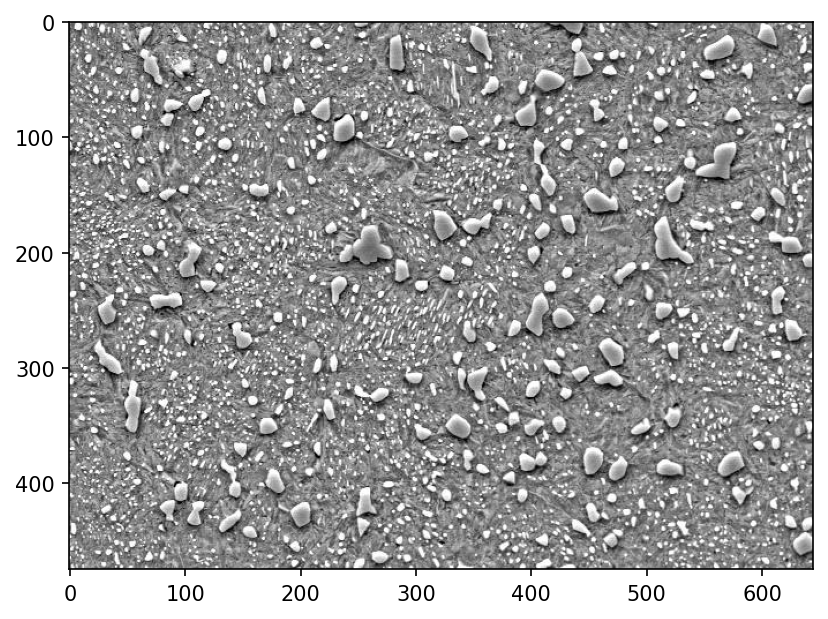

In [2]:
# Load the list of micrograph filenames and their corresponding labels from the dataset
micro_list = pickle.load(open("./dataset/micro_list.pkl", "rb"))
label_list = pickle.load(open("./dataset/label_list.pkl", "rb"))

# Look at an example micrograph filename and its corresponding label
sample_index = 400
print("Example micrograph filename:", micro_list[sample_index])
print("Corresponding label:", label_list[sample_index])
image = io.imread(f"./dataset/{micro_list[sample_index]}")
plt.imshow(image, cmap="gray")
plt.show()

# Scale Invariant Feature Transform (SIFT)

Let's look at how to calculate the keypoint features using the SIFT algorithm in OpenCV,
further details of which can be found at https://docs.opencv.org/4.x/da/df5/tutorial_py_sift_intro.html.

We will reduce the image down to a smaller patch to see the features more clearly.

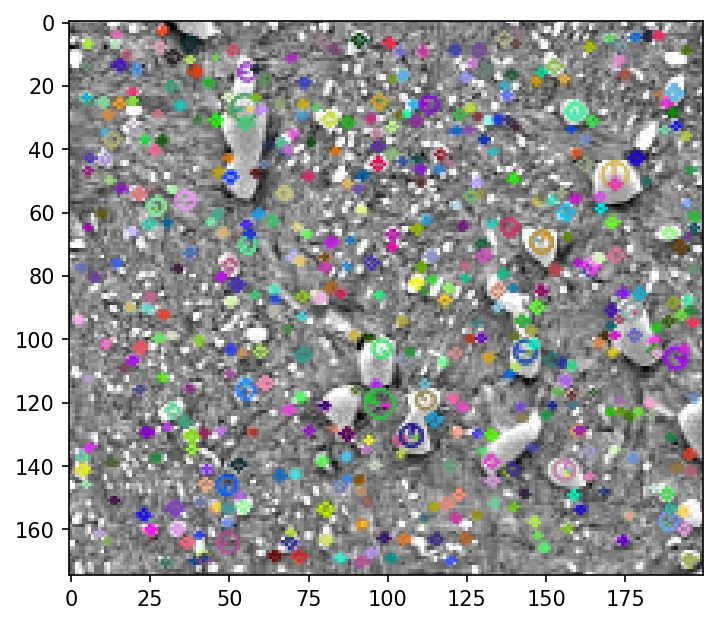

In [ ]:
# Crop the image to a smaller patch
image_patch = image[300:500, 0:200]

# Compute SIFT keypoints and descriptors for the image patch
sift = cv2.SIFT_create()
keypoints, features = sift.detectAndCompute(image_patch, None)

# Display the image with the SIFT keypoints overlaid
image_annotated=cv2.drawKeypoints(image_patch, keypoints, image_patch, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(image_annotated)
plt.show()

We can see here in this example of a spheroidite microstructure, the keypoints tend to target the precipitates (round globular grains) in the microstructure,
and the scale length they are detected at (denoted by the size of the circle annotation) corresponds to the size of the precipitate.

## Task 1

Have a play about with the `sample_id` variable in the cell where we loaded the image to see what kinds of features are detected for each microstructure class.
Samples 0-199 are carbide network, 200-399 are pearlite and 400-599 are spheroidite.

Now that we have a method for extracting keypoint features, we need to create a dictionary of the features in our dataset.
This does not have to be every single feature in the dataset.
The more we use, the more expensive the clustering algorithm will be in the next step.

In [ ]:
def get_dict_sift(root_dir, filenames, n_samples):
    r"""Get dictionary of features from list of input images.

    Parameters
    ----------
    root_dir : str
        Path to image data.
    filenames : lst
        List of image filenames.
    n_samples : int
        Number of images to use for dictionary construction. These images are randomly sampled from the list of
        filenames.

    Returns
    -------
    dict : ndarray
        Dictionary of features with shape :math:`(N, d)`, where :math:`N` is the number of features and :math:`d` is the
        length of each feature.
    """

    # Initialise progress bar
    f = IntProgress(min=0, max=n_samples)
    display(f)

    # Count the number of images and randomly sample a subset for dictionary construction
    n_images = len(filenames)
    sample_ids = np.random.choice(n_images, n_samples, replace=False)
    dict = None

    # Loop over each image in the sample to compute SIFT features and store them in the dictionary
    for n in sample_ids:
        image = io.imread(os.path.join(root_dir, filenames[n]))
        _, x_features = sift.detectAndCompute(image, None)
        if dict is None:
            dict = np.copy(x_features)
        else:
            dict = np.vstack((dict, x_features))
        f.value += 1

    return dict

In [16]:
n_samples = 200  # number of images to use for dictionary construction
dict = get_dict_sift("./dataset", micro_list, n_samples)
print("Shape of dictionary (n_features, feature_size):", dict.shape)

IntProgress(value=0, max=200)

Shape of dictionary (n_features, feature_size): (889351, 128)


We now need to train a clustering algorithm to learn how similar features can be grouped together.
Here, will use $k$-means clustering, where $k$ denotes the number of clusters.
We want to find the optimal number of clusters such that we have enough to describe the variety of features that are extracted from the images,
but not so many that similar features get treated as belonging to different clusters.

Finding this balance can be done with what is known as the "elbow" method.
This involves training the clustering algorithm with different values of $k$ and measuring the within-cluster sum of squares (WCSS).
The resulting plot should look something like an elbow (hence the name) and the value of $k$ that sits at the elbow is selected as our optimal value.

<img src="./images/elbow_diagram.png"
     alt="Markdown Monster icon"
     style="float: left; margin-right: 10px;" />

We will be using the scikit-learn implementation of $k$-means clustering in this session,
more details of which can be found at https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html.

In [6]:
k_min = 1
k_max = 40
step_size = 4
wcss = []
k_list = []

f = IntProgress(min=1, max=np.round((k_max - k_min) / step_size))
display(f)
for k in np.arange(k_min, k_max, step_size):

    kmeans = KMeans(n_clusters=int(k))
    kmeans.fit(dict)
    wcss.append(kmeans.inertia_)
    k_list += [k]

    f.value += 1

IntProgress(value=1, max=10, min=1)

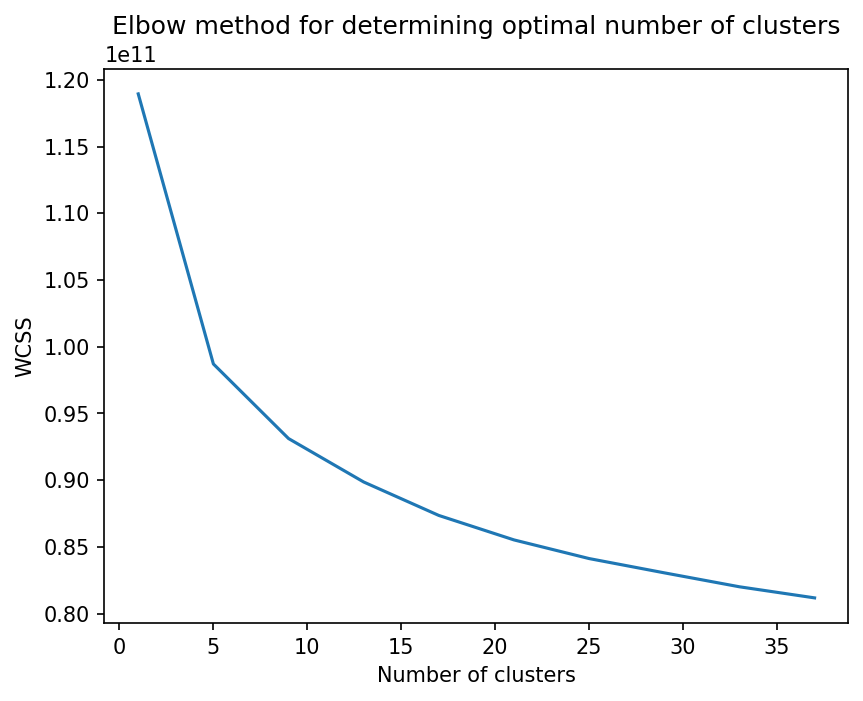

In [7]:
plt.plot(k_list, wcss)
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("Elbow method for determining optimal number of clusters")
plt.show()

We want to find the number of clusters where the rate of decrease begins to plateau.
This is much easier to identify by looking at the gradient of the WCSS.

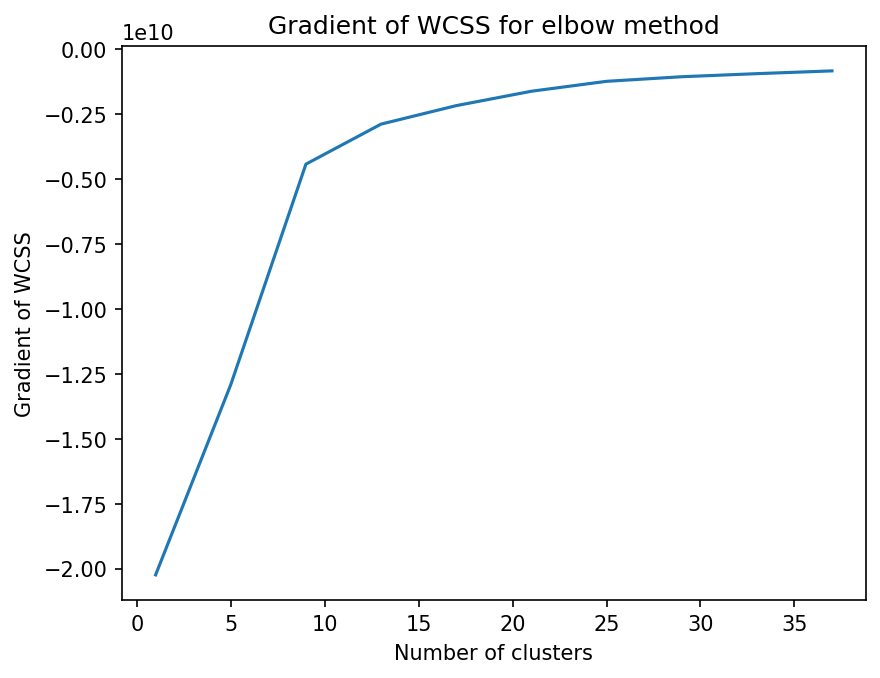

In [8]:
plt.plot(k_list, np.gradient(wcss))
plt.xlabel("Number of clusters")
plt.ylabel("Gradient of WCSS")
plt.title("Gradient of WCSS for elbow method")
plt.show()

We will choose a value of $k=10$ here and proceed with the clustering.
This is a method known as the visual bag of words (VBOW).
Each cluster centre is given a label from $0$ to $k-1$.
We can think of each cluster centre as a word in our vocabulary that we are trying to learn to describe our microstructures.
Once we have learned the vocabulary, we can take an input and calculate the dictionary of features for that image.
We can then apply the trained clustering algorithm to map all of the features in our dictionary to the nearest word in the vocabulary.
This then tells us which aspects of our vocabulary are required to describe the microstructure that has been input.

We should see that some clusters are only ever used for individual classes of microstructure.
Counting the number of features that are mapped to each cluster centre then gives us a histogram which we will use as a microstructural fingerprint.

In [9]:
# Train the k-means clustering algorithm on our discionary of features to get the cluster centers,
# which will be our visual words
k = 10
kmeans = KMeans(n_clusters=k)
kmeans.fit(dict)

# Take a random input image and compute its SIFT features
image = io.imread(os.path.join("./dataset", micro_list[0]))
_, x_features = sift.detectAndCompute(image, None)

# Assign a cluster label to each feature
labels = kmeans.predict(x_features)

# Create a histogram of visual word occurrences for the input image - this will be our microstructural fingerprint
fingerprint, _ = np.histogram(labels, bins=k)

# Normalize the fingerprint
fingerprint = fingerprint / np.sum(fingerprint)

We can now plot the fingerprints as a histogram to see how many features we have belonging to each cluster centre.

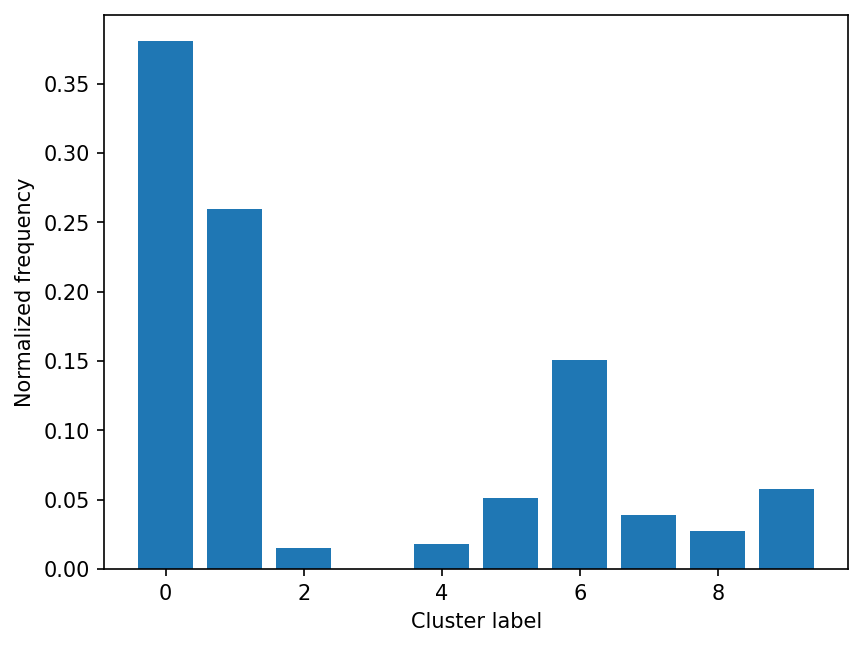

In [10]:
plt.bar(np.arange(k), fingerprint)
plt.xlabel("Cluster label")
plt.ylabel("Normalized frequency")
plt.show()

## Task 2

Repeat this fingerprinting step for some different microstructures in the dataset, with at least one from each class.
There is no need to retrain the clustering algorithm, this is for visualisation only.
We should see that microstructures from the same class have similar fingerprints,
whereas those from different classes should look relatively distinct.
However, there may be some outliers.
We can order the clusters for clearer visualisation.
Though, it is important that the ordering you use remains consistent for all visualisations.

In [11]:
# ADD CODE HERE

# Classification

We can now generate a set of fingerprints, one for each of the microstructures in our dataset,
and pass this into a support vector machine (SVM) for classification.

For training, we must split the set of fingerprints into a training set and a test set.
We will use 90% of the fingerprints and the rest will be unseen during training to validate that the model can generalise to unseen data.
This can be done once with a single train-test split, or we can use a process called $N$-fold cross validation,
where we will do $N$ train-test splits and see how the accuracy of the model varies depending on how the data was split.
This will give us a sort of uncertainty on the classification accuracy.

We will be using the scikit-learn implementation of the SVM,
more details of which can be found at https://scikit-learn.org/stable/modules/svm.html.

In [12]:
# Construct array of fingerprints for all images in the dataset
f = IntProgress(min=1, max=len(micro_list))
display(f)

fingerprints = np.zeros((len(micro_list), k))  # preacllocate array for fingerprints
for n, filename in enumerate(micro_list):
    image = io.imread(os.path.join("./dataset", filename))
    _, x_features = sift.detectAndCompute(image, None)
    labels = kmeans.predict(x_features)
    fingerprint, _ = np.histogram(labels, bins=k)
    fingerprints[n] = fingerprint / np.sum(fingerprint)
    f.value += 1

IntProgress(value=1, max=600, min=1)

In [ ]:
# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split(fingerprints, label_list, test_size=0.1, random_state=42)

# Train an SVM classifier using the chi-squared kernel and evaluate its performance on the test set
# This kernel choice is motivated by the literature, but other options exist and can be used instead
svm = SVC(kernel=chi2_kernel, C=1.0, gamma='auto').fit(X_train, y_train)
y_pred = svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Classification accuracy: {accuracy:.4f}")


## Task 3

Here we have looked at a single train-test split of the data.
Perform a 10-fold cross validation to find the average behaviour to remove the bias incurred by using only a single split.
This involves repeating the SVM training for different splits and calculating the average classification accuracy.
We can also calculate the variance of the accuracy.
Ensure that the `random_state` variable is not the same for each train-test split during your cross validation.

In [15]:
# ADD CODE HERE

# Convolutional Neural Networks (CNNs)

We will look at pretrained CNNs here, as they allow us to use a CNN without the computationally expensive requirement of training the network from scratch.
This is a process known as transfer learning, and it allows us to leverage the features that have already been learned on a large image database known as ImageNet.
There are lots of pretrained architectures that can be access in PyTorch, a Python library that is widely used in machine learning applications.
We will demonstrate using AlexNet, but you can play around with some other architectures too, if you wish.
A full list of all the available pretrained networks is available at https://docs.pytorch.org/vision/stable/models.html.

CNNs trained on image data are typically composed of two parts - feature extraction and classification.
The classification portion is important for training, as it allows a loss function to be applied,
which is then used to update the network towards predicting labels with a higher accuracy, i.e. by minimising the loss function.
If we were training from scratch with our microstructure data that we have here,
we would require the last layer in the network to have three nodes - one for each of the class labels we have in our data.
However, there are 1000 classes in ImageNet and none of them relate to microstructure in any way,
so, for transfer learning, we are required to remove the classification head and keep only the trained feature extraction portion of the network.

For transfer learning, we also need to ensure that our image data is preprocessed before being input into the network.
We must resize our micrographs to match the size of the images in the initial training data and, also, normalise each image relative to the RGB values across the initial dataset.

Let's start by loading in the pretrained model, removing the classification head and setting up our preprocessing transform.

In [23]:
import torch.nn as nn
from torchvision import models, transforms

from PIL import Image
from skimage import color
from skimage.util import img_as_ubyte

In [ ]:
# Load the pretrained model
model = models.alexnet(weights="IMAGENET1K_V1")

# Create a feature extractor by removing the final classification layer
feature_extractor = nn.Sequential(*list(model.children())[:-1])

# Set up preprocessing parameters
preprocess = transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

Now we can load an example image and look at the outputs from the network once we pass it though.
The image is converted from greyscale to RGB (1-channel to 3-channel) before passing to the preprocessing transform.
We then do an `unsqueeze` operation to add an additional dimension to the image.
This is used for batching images together, although if we only have one image this dimension will only have one element.
It is important that we add this regardless, as the network was pretrained on batched image data,
and so it is expecting that additional dimension to be there.

In [25]:
image = io.imread(f"./dataset/{micro_list[sample_index]}")
input_tensor = preprocess(Image.fromarray(color.gray2rgb(img_as_ubyte(image / np.max(image)))))
input_batch = input_tensor.unsqueeze(0)
output = feature_extractor(input_batch).detach().numpy()

print("Shape of output feature vector:", output.shape)

Shape of output feature vector: (1, 256, 6, 6)


The output shape here shows us that we have $1$ image, and there are $256$ features that have been extracted, each one of these features being a $6 \times 6$ matrix.

There a many ways we could process this information to give us a useful fingerprint for training the SVM we considered earlier.
The most straightforward method is to just flatten the stack of features into a single vector, giving us a $9216$-dimensional fingerprint.

In [26]:
fingerprint = output.flatten()
print("Shape of fingerprint:", fingerprint.shape)

Shape of fingerprint: (9216,)


## Task 4

Loop over all the images in the dataset and create an array of fingerprints with the shape `(n_fingerprints, 9126)` by using this flattening method.
Use this to then do a train-test split and train the SVM as before.
This time, use `kernel="linear"` instead of the `chi2_squared` kernel we used earlier in the SVM.

In [ ]:
# ADD CODE HERE

# VBOW With CNN Features

We can also convert the output from the CNN into a stack of features for each image with the shape $256 \times 36$.
This can then be applied across a sample of the dataset to construct a dictionary of features,
as we did with the SIFT features earlier, and construct fingerprints using the VBOW method.

## Task 5

Generate a dictionary of features and construct fingerprints using VBOW.
Train the SVM with these fingerprints.

How does the accuracy compare to the other methods we have seen today?

In [ ]:
# ADD CODE HERE

# Extension Task

We have looked here at the visual bag of words, which effectively just counts the number of features belonging to each cluster centre in the $k$-means clustering.
We can increase the amount of information contained in the fingerprint by considering higher order information, such as determining the average feature assigned to each cluster centre, rather than just counting the number of features.
Centring these means by subtracting the cluster centre and normalising with $L_2$ normalisation is a method known as the vector of locally aggregated descriptors (VLAD).

When we do the $k$-means clustering, we get a list of features and a list of corresponding labels for those features.
Can you construct a fingerprint using these average features at each cluster centre together a higher order fingerprint?

HINT: for the SIFT features, we should increase our fingerprint size from $k$-dimensional to $128 k$-dimensional, where $k$ is the number of clusters used.

In [ ]:
# ADD CODE HERE